# Laboratorio — Reinforcement Learning: un agente che impara a esplorare

### Fondazione iFAB · Corso IFTS — Machine Learning e Reti Neurali

Avete visto il video in cui un'intelligenza artificiale impara a giocare a **Pokémon** da sola, senza che nessuno le spieghi le regole? Quella è una delle applicazioni più affascinanti del **Reinforcement Learning** (apprendimento con rinforzo).

In questo laboratorio costruiamo **la stessa idea, in miniatura**: un agente che esplora una mappa a griglia e impara da solo a raggiungere l'uscita — proprio come il "topino nel labirinto" che abbiamo visto stamattina.

---

### Perché non facciamo girare direttamente il progetto Pokémon?
Il progetto originale ([PWhiddy su GitHub](https://github.com/PWhiddy/PokemonRedExperiments)) è geniale ma:
- richiede la **ROM del gioco** (protetta da copyright, non distribuibile),
- usa un **emulatore Game Boy** e una **GPU**,
- ha bisogno di **giorni di addestramento** per dare risultati.

In un pomeriggio non è fattibile. Ma il **principio è identico**: noi lo vediamo funzionare in pochi secondi, capendo ogni pezzo. Alla fine vi mostro anche la versione "adulta" (lo stesso algoritmo, PPO, usato nel progetto Pokémon).

---

### Cosa imparerete
1. Cosa sono **agente, ambiente, stato, azione, ricompensa** (in codice, non solo in teoria)
2. Come un agente bilancia **esplorazione** e **sfruttamento**
3. L'algoritmo **Q-learning**: come l'agente costruisce la sua "esperienza"
4. Vedere l'agente migliorare epoca dopo epoca e risolvere la mappa
5. (Bonus) La versione professionale con **PPO**, lo stesso metodo del progetto Pokémon

> Lavorate in gruppi di 2-3. Discutete le scelte (perché questa ricompensa? perché questo valore?) prima di scriverle.

---
# Fase 0 — Setup

Per il cuore del laboratorio ci servono solo **numpy** (calcolo) e **matplotlib** (grafici). Niente GPU, niente librerie pesanti: tutto trasparente.

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
import random

np.random.seed(42)
random.seed(42)
print("Pronti!")

Pronti!


---
# Fase 1 — L'ambiente: la mappa da esplorare

Nel Reinforcement Learning il primo passo è definire l'**ambiente** in cui l'agente vive.

La nostra mappa è una griglia. Ogni cella può essere:
- **libera** (l'agente può passarci)
- un **muro** (alberi, rocce: bloccano il passaggio)
- la **partenza** (dove inizia l'allenatore)
- l'**uscita** (l'obiettivo da raggiungere)

Costruiamola: `0` = libera, `1` = muro.

In [72]:
# La mappa: 0 = libera, 1 = muro
#### MODIFICA QUI — prova una mappa diversa (più grande, più muri) ####
# Regola: deve esistere almeno un percorso libero dalla PARTENZA all'USCITA
mappa = np.array([
    [0,0,0,1,0,0,0,0],
    [0,1,0,1,0,1,1,0],
    [0,1,0,0,0,0,1,0],
    [0,1,1,1,1,0,1,0],
    [0,0,0,0,1,0,0,0],
    [1,1,1,0,1,1,1,0],
    [0,0,0,0,0,0,0,0],
])

PARTENZA = (0, 0)   # angolo in alto a sinistra
USCITA   = (6, 7)   # angolo in basso a destra

n_righe, n_col = mappa.shape
print("Dimensione mappa:", mappa.shape)

Dimensione mappa: (7, 8)


### 1.1 Disegniamo la mappa
Visualizziamo l'ambiente: l'allenatore parte dal quadrato verde e deve raggiungere l'uscita rossa, evitando i muri (neri).

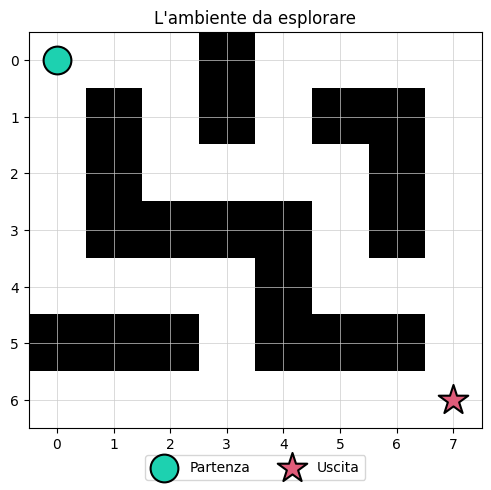

In [73]:
def disegna_mappa(ax=None, titolo="La mappa"):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    # sfondo: bianco libero, nero muri
    ax.imshow(mappa, cmap='Greys', vmin=0, vmax=1)
    # partenza e uscita
    ax.scatter(PARTENZA[1], PARTENZA[0], s=400, c='#1DD1B0', marker='o',
               edgecolors='black', linewidths=1.5, label='Partenza', zorder=3)
    ax.scatter(USCITA[1], USCITA[0], s=500, c='#E05C7A', marker='*',
               edgecolors='black', linewidths=1.5, label='Uscita', zorder=3)
    ax.set_xticks(range(n_col)); ax.set_yticks(range(n_righe))
    ax.grid(True, color='#cccccc', linewidth=0.5)
    ax.set_title(titolo)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)
    return ax

disegna_mappa(titolo="L'ambiente da esplorare")
plt.tight_layout()
plt.show()

**Domanda per il gruppo:** guardando la mappa, qual è secondo voi il percorso più corto dalla partenza all'uscita? Tenetelo a mente: vedremo se l'agente lo scopre da solo.

### 1.2 Stato e azioni
- Lo **stato** è semplicemente *dove si trova l'agente*: la coppia (riga, colonna).
- Le **azioni** possibili sono 4: muoversi **su, giù, sinistra, destra**.

In [74]:
# Le 4 azioni: variazione di (riga, colonna)
azioni = [(-1, 0),   # su
          (1, 0),    # giu
          (0, -1),   # sinistra
          (0, 1)]    # destra
nomi_azioni = ['su', 'giu', 'sinistra', 'destra']
n_azioni = 4

print("L'agente puo fare", n_azioni, "azioni:", nomi_azioni)

L'agente puo fare 4 azioni: ['su', 'giu', 'sinistra', 'destra']


---
# Fase 2 — La ricompensa: come diciamo all'agente "bravo" o "sbagliato"

L'agente non sa cosa deve fare. Lo guidiamo **solo** attraverso le ricompense. Questa è la parte più importante (e più delicata!) del Reinforcement Learning: si chiama *reward shaping*.

Le nostre regole:
- Arriva all'**uscita** → **+10** (grande premio!)
- Sbatte contro un **muro** o esce dai bordi → **−1** (penalità, e resta fermo)
- Ogni **passo normale** → **−0.1** (piccola penalità: così impara a fare in fretta, senza girare a vuoto)

> La piccola penalità a ogni passo è un trucco classico: senza, all'agente non importerebbe di trovare la strada *corta*. Nel progetto Pokémon, allo stesso modo, l'agente viene premiato per esplorare zone nuove della mappa.

In [75]:
def passo(stato, a):
    """Esegue un'azione. Restituisce: nuovo stato, ricompensa, finito?"""
    dr, dc = azioni[a]
    nr, nc = stato[0] + dr, stato[1] + dc

    # fuori dai bordi o contro un muro: resta fermo, penalita
    if nr < 0 or nr >= n_righe or nc < 0 or nc >= n_col or mappa[nr, nc] == 1:
        #### MODIFICA QUI — penaltà muro (prova: -2.0) ####
        return stato, -1.0, False

    nuovo = (nr, nc)
    if nuovo == USCITA:
        #### MODIFICA QUI — premio uscita ####
        return nuovo, 10.0, True      # premio + episodio finito
    #### MODIFICA QUI — penaltà passo normale (prova: -0.5) ####
    return nuovo, -0.1, False         # passo normale

# Proviamo: dall'angolo (0,0), andare a destra
nuovo, r, finito = passo((0, 0), 3)
print(f"Da (0,0) vado a destra -> nuovo stato {nuovo}, ricompensa {r}, finito {finito}")
# Proviamo a sbattere: dall'angolo, andare su (fuori mappa)
nuovo, r, finito = passo((0, 0), 0)
print(f"Da (0,0) vado su (fuori) -> nuovo stato {nuovo}, ricompensa {r}, finito {finito}")

Da (0,0) vado a destra -> nuovo stato (0, 1), ricompensa -0.1, finito False
Da (0,0) vado su (fuori) -> nuovo stato (0, 0), ricompensa -1.0, finito False


---
# Fase 3 — Q-learning: come l'agente costruisce l'esperienza

Come fa l'agente a imparare? Tiene una specie di **"taccuino dell'esperienza"** chiamato **tabella Q**.

Per ogni cella della mappa e per ogni azione possibile, la tabella Q segna **quanto è promettente** quella azione in quella posizione. All'inizio è tutta a zero: l'agente non sa nulla.

### Il ciclo
1. L'agente guarda dove si trova (**stato**)
2. Sceglie un'**azione**
3. Riceve una **ricompensa** e si sposta in un nuovo stato
4. **Aggiorna la tabella Q**: se l'azione ha portato a qualcosa di buono, alza il punteggio

### Esplorazione vs Sfruttamento
- All'inizio l'agente esplora: prova azioni a caso per scoprire la mappa
- Man mano che impara, sfrutta sempre più ciò che sa, scegliendo le azioni migliori

Questo si controlla con **epsilon**: la probabilità di fare una mossa a caso. Parte alto e scende piano piano.

In [76]:
# La tabella Q: per ogni cella (riga, col) e ogni azione, un punteggio. Inizia a zero.
Q = np.zeros((n_righe, n_col, n_azioni))

def scegli_azione(stato, epsilon):
    """Strategia epsilon-greedy: a volte esplora (a caso), a volte sfrutta (la migliore)."""
    if np.random.rand() < epsilon:
        return np.random.randint(n_azioni)        # ESPLORA: mossa a caso
    else:
        return np.argmax(Q[stato[0], stato[1]])   # SFRUTTA: la migliore conosciuta

print("Tabella Q creata:", Q.shape, "(righe x colonne x azioni)")
print("All'inizio e tutta a zero: l'agente non sa nulla.")

Tabella Q creata: (7, 8, 4) (righe x colonne x azioni)
All'inizio e tutta a zero: l'agente non sa nulla.


### La regola di aggiornamento
Quando l'agente fa un'azione e vede il risultato, aggiorna la tabella Q così:

`Q[stato, azione] = Q[stato, azione] + α × (ricompensa + γ × max(Q[nuovo_stato]) − Q[stato, azione])`

In parole semplici: *"correggi la tua stima di quanto era buona questa mossa, avvicinandola alla ricompensa appena ricevuta più la promessa del futuro"*.

- **α (alpha)** = quanto velocemente impara (learning rate)
- **γ (gamma)** = quanto tiene conto delle ricompense future (lungimiranza)

Non serve impararla a memoria: l'importante è capire che l'agente *aggiusta le sue stime in base all'esperienza*.

---
# Fase 4 — Addestramento: l'agente impara

Ora lasciamo l'agente libero di esplorare per tanti **episodi** (un episodio = un tentativo dalla partenza fino all'uscita o al limite di passi). A ogni episodio impara un po'.

Eseguite la cella e guardate i numeri: all'inizio le ricompense saranno molto negative (sbatte ovunque), poi miglioreranno.

In [77]:
# Iperparametri (le "manopole" dell'apprendimento)

#### MODIFICA QUI — cambia questi valori e osserva come cambia l'apprendimento ####
alpha = 0.1        # learning rate
gamma = 0.95       # importanza del futuro
epsilon = 1.0      # prova: 0.0 (nessuna esplorazione) — cosa succede? Perché?
epsilon_min = 0.05
epsilon_decay = 0.995
episodi = 600      # prova: 50 — l'agente fa ancora in tempo a imparare?
max_passi = 200

# Ripartiamo da una tabella Q pulita
Q = np.zeros((n_righe, n_col, n_azioni))
storico_ricompense = []
storico_passi = []      # passi per episodio (None se non ha raggiunto l'uscita)

for ep in range(episodi):
    stato = PARTENZA
    ricompensa_totale = 0
    finito = False
    passi = 0

    while not finito and passi < max_passi:
        a = scegli_azione(stato, epsilon)
        nuovo_stato, r, finito = passo(stato, a)

        # aggiornamento Q-learning
        vecchio = Q[stato[0], stato[1], a]
        futuro = np.max(Q[nuovo_stato[0], nuovo_stato[1]])
        Q[stato[0], stato[1], a] = vecchio + alpha * (r + gamma * futuro - vecchio)

        stato = nuovo_stato
        ricompensa_totale += r
        passi += 1

    epsilon = max(epsilon_min, epsilon * epsilon_decay)   # esplora sempre meno
    storico_ricompense.append(ricompensa_totale)
    storico_passi.append(passi if finito else None)

    if (ep + 1) % 100 == 0:
        media = np.mean(storico_ricompense[-100:])
        print(f"Episodio {ep+1:4d} | ricompensa media (ultimi 100): {media:6.2f} | epsilon: {epsilon:.2f}")

print("\nAddestramento finito!")

episodio_ottimale = np.argmax(storico_ricompense) + 1
ricompensa_ottimale = max(storico_ricompense)
print(f"Episodio ottimale: {episodio_ottimale} su {episodi} (ricompensa: {ricompensa_ottimale:.2f})")

passi_validi = [(p, i + 1) for i, p in enumerate(storico_passi) if p is not None]
if passi_validi:
    min_passi, ep_min_passi = min(passi_validi)
    ricompensa_ep_min = storico_ricompense[ep_min_passi - 1]
    print(f"Percorso più corto: {min_passi} passi (episodio {ep_min_passi}, ricompensa: {ricompensa_ep_min:.2f})")
else:
    print("L'agente non ha mai raggiunto l'uscita — prova ad aumentare gli episodi.")

Episodio  100 | ricompensa media (ultimi 100): -25.55 | epsilon: 0.61
Episodio  200 | ricompensa media (ultimi 100):   1.73 | epsilon: 0.37
Episodio  300 | ricompensa media (ultimi 100):   6.15 | epsilon: 0.22
Episodio  400 | ricompensa media (ultimi 100):   7.55 | epsilon: 0.13
Episodio  500 | ricompensa media (ultimi 100):   7.87 | epsilon: 0.08
Episodio  600 | ricompensa media (ultimi 100):   8.39 | epsilon: 0.05

Addestramento finito!
Episodio ottimale: 211 su 600 (ricompensa: 8.80)
Percorso più corto: 13 passi (episodio 211, ricompensa: 8.80)


**Cosa è successo?** All'inizio l'agente vagava a caso (ricompensa media molto negativa). Man mano che `epsilon` scende, sfrutta ciò che ha imparato e la ricompensa media sale. Vediamolo in un grafico.

---
# Fase 5 — I risultati: vediamo cosa ha imparato

### 5.1 La curva di apprendimento
Se l'agente impara davvero, la ricompensa per episodio deve salire nel tempo.

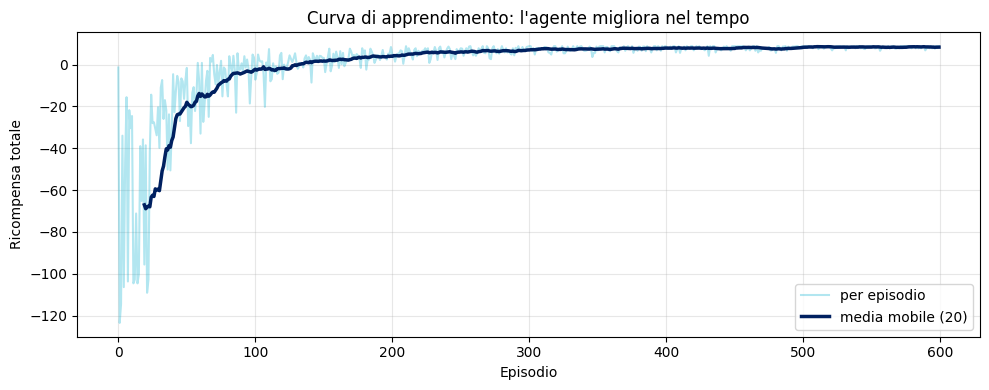

In [78]:
plt.figure(figsize=(10, 4))
plt.plot(storico_ricompense, alpha=0.3, color='#00ADCF', label='per episodio')
# media mobile per vedere il trend
finestra = 20
if len(storico_ricompense) >= finestra:
    media_mobile = np.convolve(storico_ricompense, np.ones(finestra)/finestra, mode='valid')
    plt.plot(range(finestra-1, len(storico_ricompense)), media_mobile,
             color='#002060', linewidth=2.5, label=f'media mobile ({finestra})')
plt.xlabel('Episodio'); plt.ylabel('Ricompensa totale')
plt.title('Curva di apprendimento: l\'agente migliora nel tempo')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.2 La strategia appresa
Per ogni cella, qual è l'azione che l'agente ha imparato a preferire? Disegniamo una **freccia** in ogni cella: è la "mappa mentale" dell'agente.

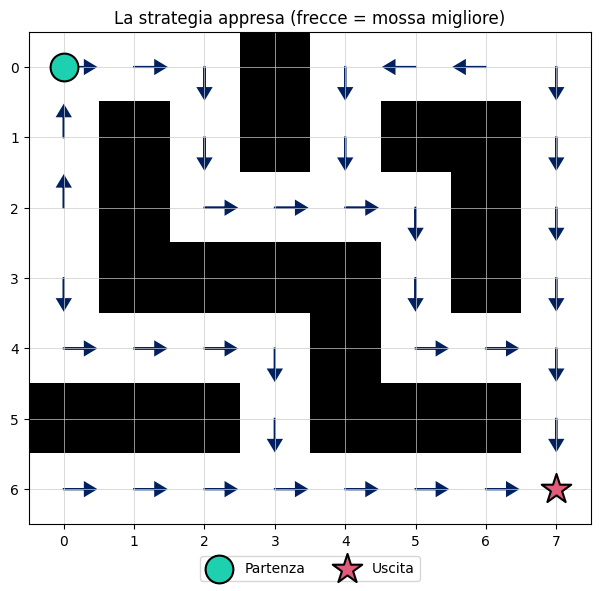

In [79]:
fig, ax = plt.subplots(figsize=(7, 6))
disegna_mappa(ax, titolo="La strategia appresa (frecce = mossa migliore)")

frecce = {0:(0,-0.3), 1:(0,0.3), 2:(-0.3,0), 3:(0.3,0)}  # su, giu, sin, des (dx, dy)
for i in range(n_righe):
    for j in range(n_col):
        if mappa[i,j]==1 or (i,j)==USCITA:
            continue
        a = np.argmax(Q[i,j])
        dx, dy = frecce[a]
        ax.arrow(j, i, dx, dy, head_width=0.18, head_length=0.15,
                 fc='#002060', ec='#002060', linewidth=1.5)
plt.tight_layout()
plt.show()

**Osservate le frecce:** formano un "fiume" che scorre dalla partenza verso l'uscita. L'agente ha costruito una strategia coerente per ogni punto della mappa, senza che nessuno gliela abbia insegnata.

### 5.3 Guardiamo l'agente risolvere la mappa
Facciamo seguire all'agente la strategia appresa, e animiamo il percorso.

In [80]:
# Ricostruiamo il percorso seguendo sempre la mossa migliore
stato = PARTENZA
percorso = [stato]
finito = False
passi = 0
while not finito and passi < 100:
    a = np.argmax(Q[stato[0], stato[1]])
    stato, r, finito = passo(stato, a)
    percorso.append(stato)
    passi += 1

print(f"L'agente raggiunge l'uscita in {len(percorso)-1} passi.")

# Animazione
fig, ax = plt.subplots(figsize=(7, 6))
def aggiorna(frame):
    ax.clear()
    disegna_mappa(ax, titolo=f"L'agente in azione - passo {frame}")
    r, c = percorso[frame]
    ax.scatter(c, r, s=400, c='#EE7008', marker='o', edgecolors='black',
               linewidths=2, zorder=4)
    # scia
    if frame > 0:
        ys = [p[0] for p in percorso[:frame+1]]
        xs = [p[1] for p in percorso[:frame+1]]
        ax.plot(xs, ys, color='#EE7008', linewidth=2, alpha=0.6, zorder=2)

anim = animation.FuncAnimation(fig, aggiorna, frames=len(percorso), interval=400, repeat=True)
plt.close()
HTML(anim.to_jshtml())

L'agente raggiunge l'uscita in 13 passi.


**Ce l'ha fatta!** L'agente ha imparato da solo a navigare la mappa, esattamente come il "topino nel labirinto" — e come l'AI che impara a giocare a Pokémon, solo molto più semplice.

---
# Sezione Avanzata — Un nuovo labirinto, regole vostre

Avete visto come funziona il Q-learning. Ora la sfida è diversa: il labirinto è già disegnato, ma le **regole sono incomplete**. Tocca a voi definirle.

Il nuovo labirinto ha un ingrediente in più rispetto a quello di prima: le **trappole** (`2`), celle pericolose (ghiaccio, fango, zona buia — voi decidete il significato). A differenza di un muro, la trappola *non blocca* l'agente: ci può passare, ma con conseguenze che voi scegliete.

**Prima di toccare il codice, discutete nel gruppo:**
1. La trappola deve avere una penaltà più o meno grave del muro? Perché?
2. La trappola termina l'episodio (l'agente "cade") oppure lo rallenta solo?
3. Con queste regole, qual è il percorso che vi aspettate che l'agente preferisca?

> **Vincolo:** le vostre scelte devono essere **diverse** da quelle del labirinto base — non copiate i valori precedenti!

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
from matplotlib.colors import ListedColormap

# ============================================================
# Costruite il vostro labirinto!
#
# Regole:
#   0 = cella libera
#   1 = muro (l'agente non può passarci)
#   2 = trappola (l'agente ci può entrare, ma con conseguenze che decidete voi)
#
# Vincoli:
#   - deve esistere almeno un percorso libero dalla PARTENZA_ADV all'USCITA_ADV
#   - la griglia può avere qualsiasi dimensione (es. 6x8, 9x10, 12x12...)
#   - impostate PARTENZA_ADV e USCITA_ADV in celle libere (0 o 2)
#
# Esempio di riferimento (9x10):
#   [0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
#   [0, 2, 1, 0, 1, 0, 1, 0, 1, 0],
#   [0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
#   [1, 1, 1, 0, 1, 2, 1, 1, 1, 0],
#   [0, 0, 0, 0, 0, 0, 0, 2, 1, 0],
#   [0, 1, 1, 1, 1, 1, 0, 0, 0, 0],
#   [0, 2, 0, 0, 0, 1, 1, 1, 0, 1],
#   [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
#   [1, 0, 0, 0, 1, 2, 0, 1, 0, 0],
# ============================================================

mappa_adv = np.array([
    # scrivete qui il vostro labirinto
])

PARTENZA_ADV = (0, 0)   # (riga, colonna)  

n_righe_adv, n_col_adv = mappa_adv.shape

USCITA_ADV = (n_righe_adv - 1, n_col_adv - 1)  # (riga, colonna) — ultima cella raggiungibile (# angolo in basso a destra)

# Visualizzazione — bianco = libero, nero = muro, arancione = trappola
fig, ax = plt.subplots(figsize=(max(6, n_col_adv), max(4, n_righe_adv)))
cmap_adv = ListedColormap(['white', 'black', '#FF8C00'])
ax.imshow(mappa_adv, cmap=cmap_adv, vmin=0, vmax=2)
ax.scatter(PARTENZA_ADV[1], PARTENZA_ADV[0], s=400, c='#1DD1B0', marker='o',
           edgecolors='black', linewidths=1.5, label='Partenza', zorder=3)
ax.scatter(USCITA_ADV[1], USCITA_ADV[0], s=500, c='#E05C7A', marker='*',
           edgecolors='black', linewidths=1.5, label='Uscita', zorder=3)
ax.set_xticks(range(n_col_adv)); ax.set_yticks(range(n_righe_adv))
ax.grid(True, color='#cccccc', linewidth=0.5)
ax.set_title('Il vostro labirinto')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.06), ncol=2)
plt.tight_layout(); plt.show()
print(f"Dimensione: {n_righe_adv}x{n_col_adv} | Trappole: {(mappa_adv == 2).sum()} | Muri: {(mappa_adv == 1).sum()}")

ValueError: not enough values to unpack (expected 2, got 1)

In [ ]:
azioni_adv = [(-1, 0), (1, 0), (0, -1), (0, 1)]   # su, giu, sinistra, destra
n_azioni_adv = 4

def passo_adv(stato, a):
    """Funzione passo per il labirinto avanzato. Completate i ??? con le vostre scelte."""
    dr, dc = azioni_adv[a]
    nr, nc = stato[0] + dr, stato[1] + dc

    # Fuori dai bordi
    if nr < 0 or nr >= n_righe_adv or nc < 0 or nc >= n_col_adv:
        #### MODIFICA QUI — penaltà per uscita dai bordi ####
        return stato, -???, False

    # Muro
    if mappa_adv[nr, nc] == 1:
        #### MODIFICA QUI — penaltà muro (diversa da -1.0 della versione base!) ####
        return stato, -???, False

    nuovo = (nr, nc)

    # Trappola/Premio: l'agente ci può entrare, ma con conseguenze
    if mappa_adv[nr, nc] == 2:
        #### MODIFICA QUI — penaltà trappola e: finisce l'episodio? True o False? ####
        return nuovo, -???, ???   # (penaltà/premio, episodio_finito?)

    # Uscita
    if nuovo == USCITA_ADV:
        #### MODIFICA QUI — premio uscita (diverso da +10.0 della versione base!) ####
        return nuovo, +???, True

    # Passo normale
    #### MODIFICA QUI — penaltà passo normale (diversa da -0.1 della versione base!) ####
    return nuovo, -???, False

print("Funzione passo_adv definita. Ora completate tutti i ??? prima di eseguire l'addestramento.")

SyntaxError: invalid syntax (2744687375.py, line 12)

In [ ]:
#### MODIFICA QUI — scegliete i parametri di apprendimento ####
# Devono essere diversi da quelli della versione base (alpha=0.1, gamma=0.95, epsilon=1.0,
# epsilon_min=0.05, epsilon_decay=0.995, episodi=600, max_passi=200)
alpha_adv         = ???
gamma_adv         = ???
epsilon_adv       = ???
epsilon_min_adv   = ???
epsilon_decay_adv = ???
episodi_adv       = ???
max_passi_adv     = ???

# --- Addestramento (non modificare sotto questa riga) ---
Q_adv = np.zeros((n_righe_adv, n_col_adv, n_azioni_adv))
storico_adv = []

for ep in range(episodi_adv):
    stato = PARTENZA_ADV
    tot = 0; finito = False; passi = 0
    while not finito and passi < max_passi_adv:
        if np.random.rand() < epsilon_adv:
            a = np.random.randint(n_azioni_adv)
        else:
            a = np.argmax(Q_adv[stato[0], stato[1]])
        nuovo_stato, r, finito = passo_adv(stato, a)
        vecchio = Q_adv[stato[0], stato[1], a]
        futuro  = np.max(Q_adv[nuovo_stato[0], nuovo_stato[1]])
        Q_adv[stato[0], stato[1], a] = vecchio + alpha_adv * (r + gamma_adv * futuro - vecchio)
        stato = nuovo_stato; tot += r; passi += 1
    epsilon_adv = max(epsilon_min_adv, epsilon_adv * epsilon_decay_adv)
    storico_adv.append(tot)
    intervallo = max(1, episodi_adv // 6)
    if (ep + 1) % intervallo == 0:
        media = np.mean(storico_adv[-intervallo:])
        print(f"Episodio {ep+1:4d} | media: {media:6.2f} | epsilon: {epsilon_adv:.3f}")

print("\nAddestramento avanzato finito!")

plt.figure(figsize=(10, 3))
plt.plot(storico_adv, alpha=0.3, color='#FF8C00', label='per episodio')
if len(storico_adv) >= 20:
    mm = np.convolve(storico_adv, np.ones(20)/20, mode='valid')
    plt.plot(range(19, len(storico_adv)), mm, color='#8B0000', linewidth=2, label='media mobile (20)')
plt.xlabel('Episodio'); plt.ylabel('Ricompensa totale')
plt.title("Curva di apprendimento — labirinto avanzato")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [ ]:
# Percorso finale dell'agente addestrato nel labirinto avanzato
stato = PARTENZA_ADV
percorso_adv = [stato]
finito = False; passi = 0
while not finito and passi < 300:
    a = np.argmax(Q_adv[stato[0], stato[1]])
    stato, r, finito = passo_adv(stato, a)
    percorso_adv.append(stato)
    passi += 1

if finito and stato == USCITA_ADV:
    print(f"L'agente raggiunge l'uscita in {len(percorso_adv)-1} passi.")
else:
    print("L'agente non ha trovato l'uscita. Rivedete le ricompense o aumentate gli episodi.")

# Visualizzazione
cmap_adv2 = ListedColormap(['white', 'black', '#FF8C00'])
fig, ax = plt.subplots(figsize=(8, 5))
def aggiorna_adv(frame):
    ax.clear()
    ax.imshow(mappa_adv, cmap=cmap_adv2, vmin=0, vmax=2)
    ax.scatter(PARTENZA_ADV[1], PARTENZA_ADV[0], s=300, c='#1DD1B0', marker='o', edgecolors='black', linewidths=1.5, zorder=3)
    ax.scatter(USCITA_ADV[1], USCITA_ADV[0], s=400, c='#E05C7A', marker='*', edgecolors='black', linewidths=1.5, zorder=3)
    ax.set_xticks(range(n_col_adv)); ax.set_yticks(range(n_righe_adv))
    ax.grid(True, color='#cccccc', linewidth=0.5)
    ax.set_title(f'Agente avanzato — passo {frame}')
    r, c = percorso_adv[frame]
    ax.scatter(c, r, s=350, c='#EE7008', marker='o', edgecolors='black', linewidths=2, zorder=4)
    if frame > 0:
        ys = [p[0] for p in percorso_adv[:frame+1]]
        xs = [p[1] for p in percorso_adv[:frame+1]]
        ax.plot(xs, ys, color='#EE7008', linewidth=2, alpha=0.6, zorder=2)
anim_adv = animation.FuncAnimation(fig, aggiorna_adv, frames=len(percorso_adv), interval=400, repeat=True)
plt.close()
HTML(anim_adv.to_jshtml())

**Confrontate con il gruppo vicino:** le vostre scelte di ricompensa hanno portato a percorsi diversi? L'agente evita le trappole o le attraversa lo stesso? Perché?

---
# Conclusioni

Oggi avete costruito un sistema di Reinforcement Learning **da zero** e l'avete visto imparare.

### Cosa portate a casa
- Il RL non impara da un dataset pronto, ma **dall'esperienza**: agire, ricevere feedback, correggere
- I quattro ingredienti: **agente, ambiente, azione, ricompensa**
- Il dilemma **esplorazione vs sfruttimento**
- Le **ricompense** sono il modo con cui guidiamo l'agente — progettarle bene è metà del lavoro
- Lo stesso principio, scalato con le reti neurali (**PPO**), fa giocare un'AI a Pokémon, guida i robot, ottimizza i magazzini

### Dove si usa nel mondo reale
Robotica, auto a guida autonoma, gestione energetica, trading, sistemi di raccomandazione, logistica — ovunque ci sia da prendere decisioni in sequenza in un ambiente che cambia.

Complimenti per il lavoro di oggi!